In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../../'))

from src.utils.utils import load_file

import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

#### `Restaurant Recipes Analysis`

In [2]:
# Load Data 

# Restaurant food consumption without ingredient quantities
restaurant_file = '../../data/kaggle/Restaurant_food_consumption_upd.csv'
df_restaurant_food = load_file(restaurant_file)

#### Number of orders for each menu recipe

Number of restaurant recipes:  43
Total number of restaurant orders from January to June:  18100


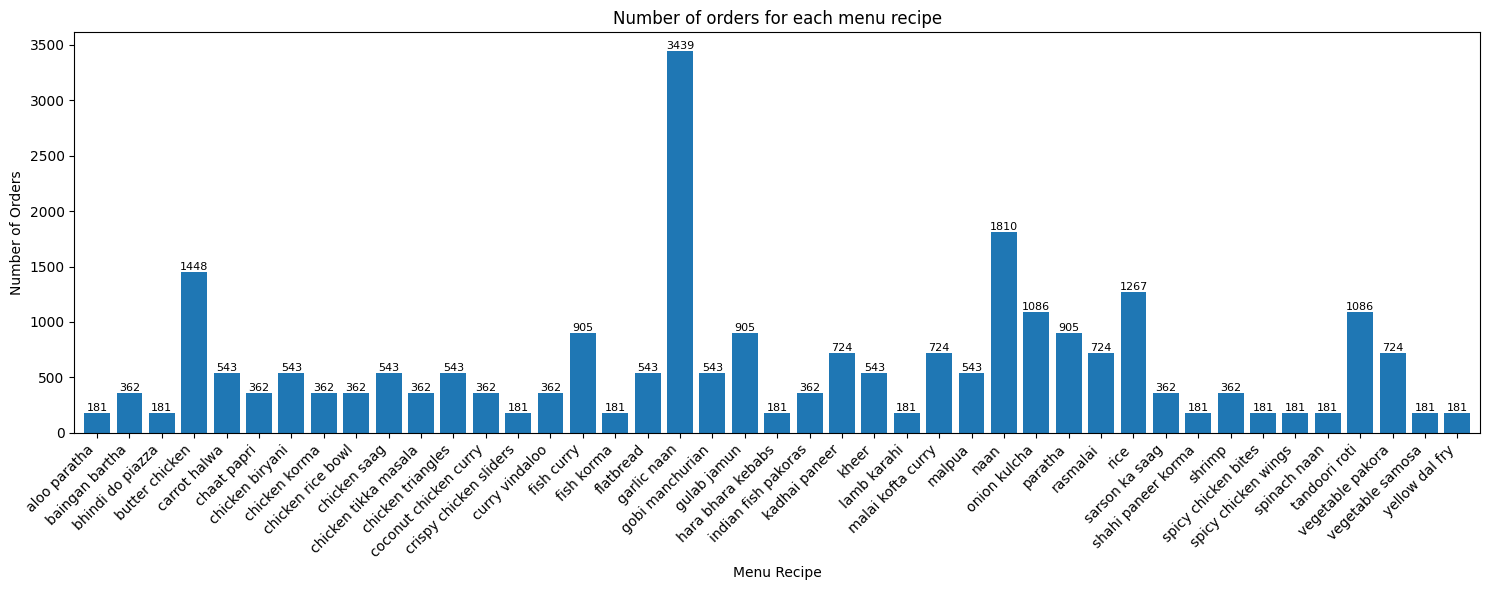

In [3]:
# Occurrences of Each Recipe

print("Number of restaurant recipes: ", len(df_restaurant_food['MenuItem'].value_counts()))
print("Total number of restaurant orders from January to June: ", len(df_restaurant_food))


order_counts = df_restaurant_food.groupby(['MenuItem', 'ItemQty']).size().reset_index(name='Order Count')
order_counts['Total Order Counts'] = order_counts['ItemQty'] * order_counts['Order Count']
total_orders_per_recipe = order_counts.groupby('MenuItem', as_index=False)['Total Order Counts'].sum()
#display(total_orders_per_recipe)

# Plot the counts
plt.figure(figsize=(15, 6))
#recipe_counts.plot(kind='bar')
bars = plt.bar(total_orders_per_recipe['MenuItem'], total_orders_per_recipe['Total Order Counts'])
plt.title('Number of orders for each menu recipe')
plt.xlabel('Menu Recipe')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')

# Remove space between the first and last bars and the edges of the plot
plt.xlim(-0.7, len(total_orders_per_recipe['MenuItem']) - 0.3)

#  automatically adjusts the padding between and around subplots to minimize overlap and ensure that all elements are displayed properly.
plt.tight_layout()  

# Annotate each bar with the count of orders
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=8)

plt.show()

In [4]:
### Check some values from recipe counts

# Recipe: chicken biryani
count_recipe1 = df_restaurant_food[df_restaurant_food['MenuItem'] == 'chicken biryani'].value_counts()
print("Number of chicken biryani ocurrences:", len(count_recipe1))

# Recipe: chicken korma
count_recipe2 = df_restaurant_food[df_restaurant_food['MenuItem'] == 'chicken korma'].value_counts()
print("Number of chicken korma ocurrences:", len(count_recipe2))

# Recipe: chicken rice bowl 
count_recipe3 = df_restaurant_food[df_restaurant_food['MenuItem'] == 'chicken rice bowl'].value_counts()
print("Number of chicken rice bowl ocurrences:", len(count_recipe3))

# Recipe: chicken saag
count_recipe4 = df_restaurant_food[df_restaurant_food['MenuItem'] == 'chicken saag'].value_counts()
print("Number of chicken saag ocurrences:", len(count_recipe4))

# Recipe: shrimp
count_recipe5 = df_restaurant_food[df_restaurant_food['MenuItem'] == 'shrimp'].value_counts()
print("Number of chicken saag ocurrences:", len(count_recipe5))

# Recipe: spicy chicken bites
count_recipe6 = df_restaurant_food[df_restaurant_food['MenuItem'] == 'spicy chicken bites'].value_counts()
print("Number of spicy chicken bites ocurrences:", len(count_recipe6))

Number of chicken biryani ocurrences: 362
Number of chicken korma ocurrences: 362
Number of chicken rice bowl ocurrences: 181
Number of chicken saag ocurrences: 362
Number of chicken saag ocurrences: 181
Number of spicy chicken bites ocurrences: 181


In [5]:
# Convert Date_time to datetime
df_restaurant_food['DateTime'] = pd.to_datetime(df_restaurant_food['DateTime'])
# Extract month and year
df_restaurant_food['YearMonth'] = df_restaurant_food['DateTime'].dt.to_period('M')

**Orders placed every month**

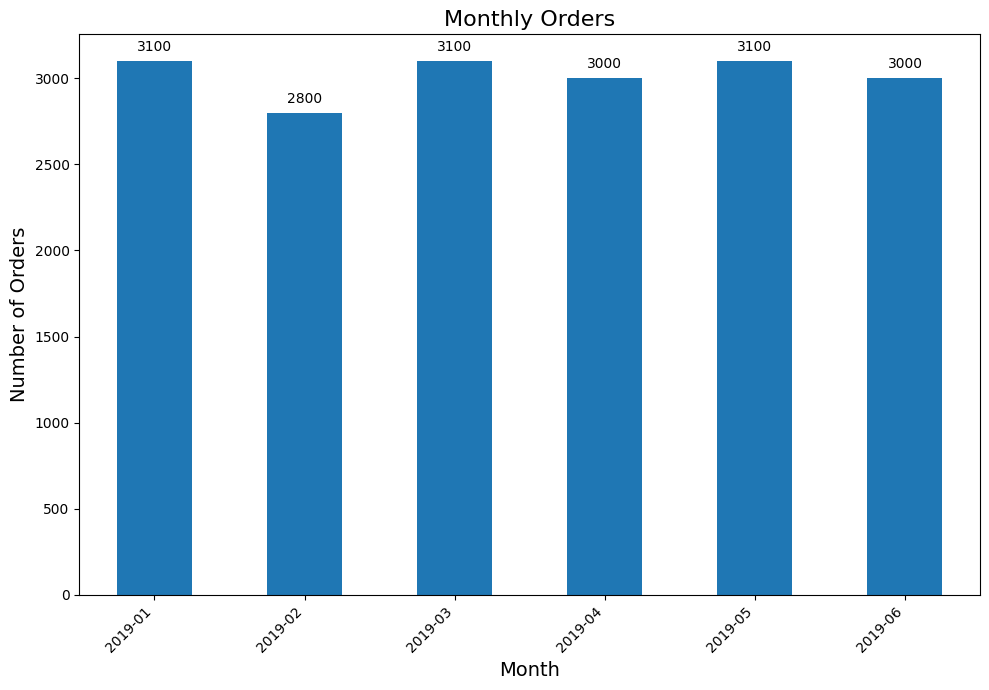

In [6]:
###TODO: Count how many orders were ordered each month

monthly_recipe_usage = df_restaurant_food['YearMonth'].value_counts().sort_index()

# Plot the counts
plt.figure(figsize=(10, 7))
ax = monthly_recipe_usage.plot(kind='bar')

# Annotate the bars with the counts
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.title('Monthly Orders', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of Orders', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()  # Automatically adjusts the padding between and around subplots
plt.show()

In [7]:
# df_filtered = df_restaurant_food[df_restaurant_food['MenuItem'] == 'gobi manchurian']

# # Ensure 'DateTime' is a datetime object
# df_filtered['DateTime'] = pd.to_datetime(df_filtered['DateTime'])

# # Set 'DateTime' as the index
# df_filtered.set_index('DateTime', inplace=True)

# # Resample by day ('D') and sum the 'ItemQty'
# df_groupby_datetime = df_filtered['ItemQty'].resample('D').sum().reset_index()
# display(df_groupby_datetime)

**Orders placed in JANUARY**

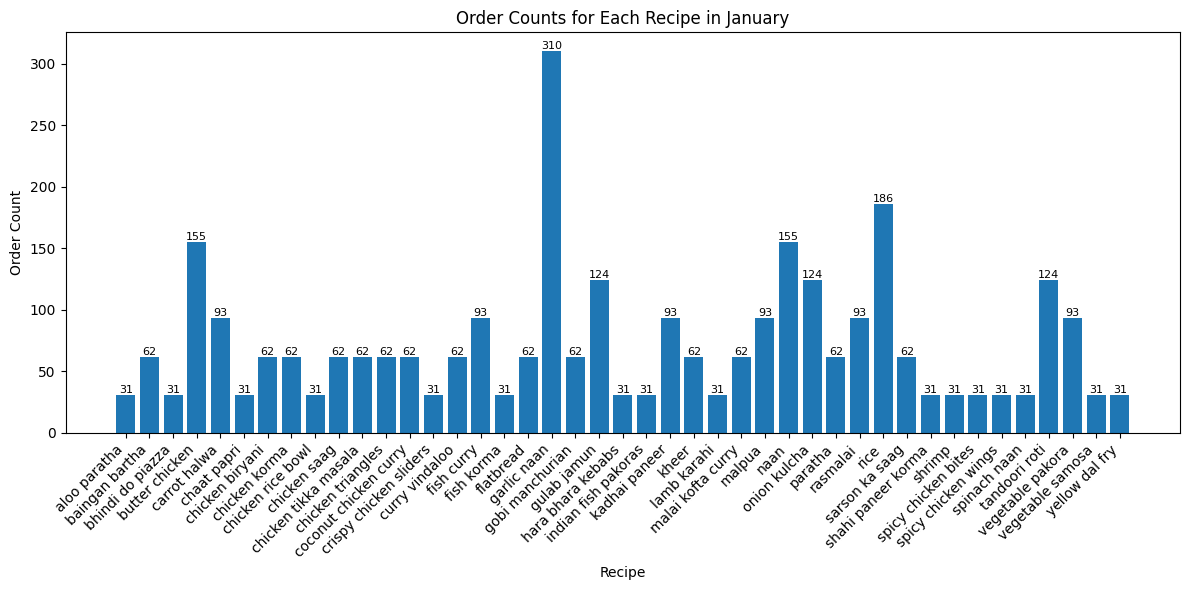

In [8]:
# Filter data for January and group by YearMonth and Recipe
january_orders = df_restaurant_food[df_restaurant_food['DateTime'].dt.month == 1]
order_counts = january_orders.groupby(['YearMonth', 'MenuItem']).size().reset_index(name='Order Count')

# Plot the data
plt.figure(figsize=(12, 6))
bars = plt.bar(order_counts['MenuItem'], order_counts['Order Count'])
plt.xlabel('Recipe')
plt.ylabel('Order Count')
plt.title('Order Counts for Each Recipe in January')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Annotate each bar with the count of orders
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=8)

plt.show()


**Orders placed in February**

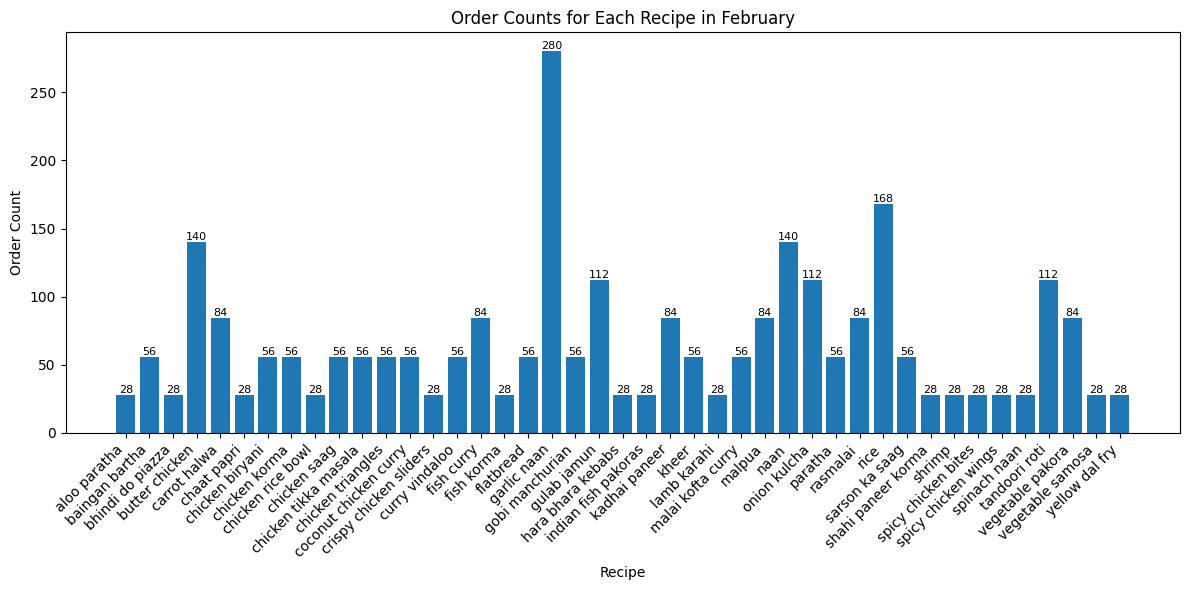

In [9]:
# Filter data for February and group by YearMonth and Recipe
february_orders = df_restaurant_food[df_restaurant_food['DateTime'].dt.month == 2]
order_counts = february_orders.groupby(['YearMonth', 'MenuItem']).size().reset_index(name='Order Count')

# Plot the data
plt.figure(figsize=(12, 6))
bars = plt.bar(order_counts['MenuItem'], order_counts['Order Count'])
plt.xlabel('Recipe')
plt.ylabel('Order Count')
plt.title('Order Counts for Each Recipe in February')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Annotate each bar with the count of orders
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=8)

plt.show()

**Orders placed in March**

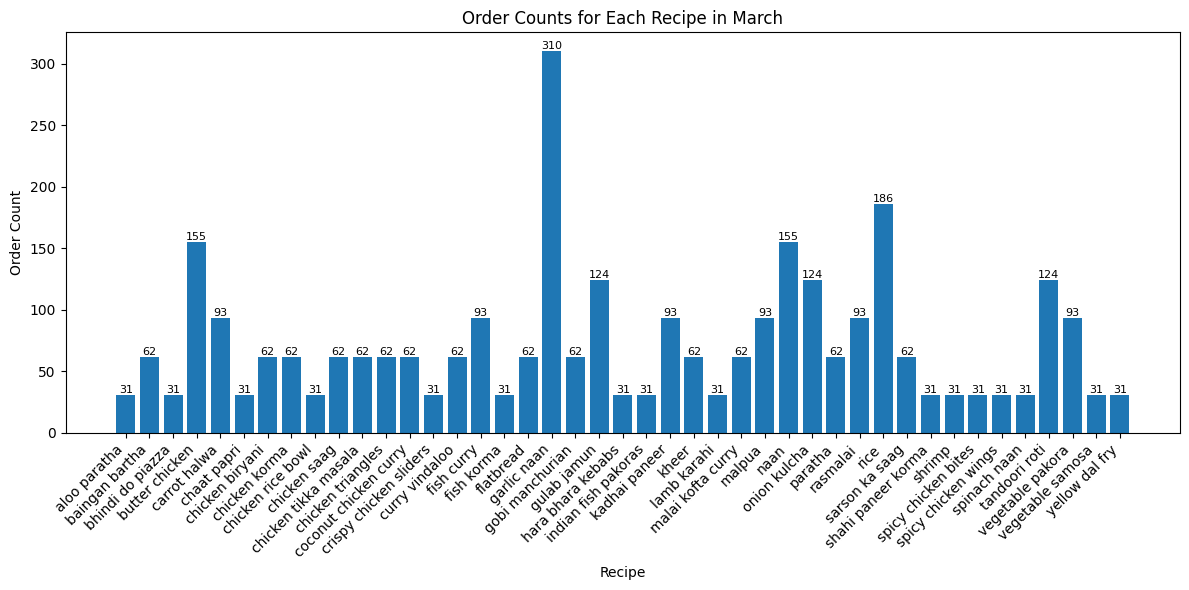

In [10]:
# Filter data for March and group by YearMonth and Recipe
march_orders = df_restaurant_food[df_restaurant_food['DateTime'].dt.month == 3]
order_counts = march_orders.groupby(['YearMonth', 'MenuItem']).size().reset_index(name='Order Count')

# Plot the data
plt.figure(figsize=(12, 6))
bars = plt.bar(order_counts['MenuItem'], order_counts['Order Count'])
plt.xlabel('Recipe')
plt.ylabel('Order Count')
plt.title('Order Counts for Each Recipe in March')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Annotate each bar with the count of orders
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=8)

plt.show()

**Orders placed in April**

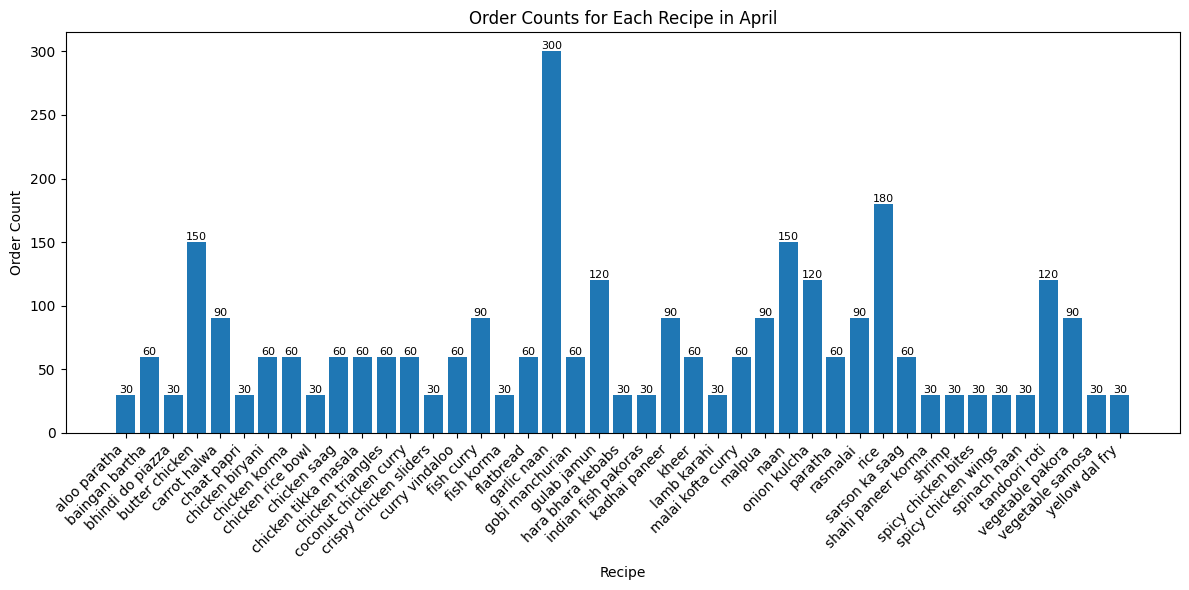

In [11]:
# Filter data for April and group by YearMonth and Recipe
april_orders = df_restaurant_food[df_restaurant_food['DateTime'].dt.month == 4]
order_counts = april_orders.groupby(['YearMonth', 'MenuItem']).size().reset_index(name='Order Count')

# Plot the data
plt.figure(figsize=(12, 6))
bars = plt.bar(order_counts['MenuItem'], order_counts['Order Count'])
plt.xlabel('Recipe')
plt.ylabel('Order Count')
plt.title('Order Counts for Each Recipe in April')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Annotate each bar with the count of orders
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=8)

plt.show()

**Orders placed in May**

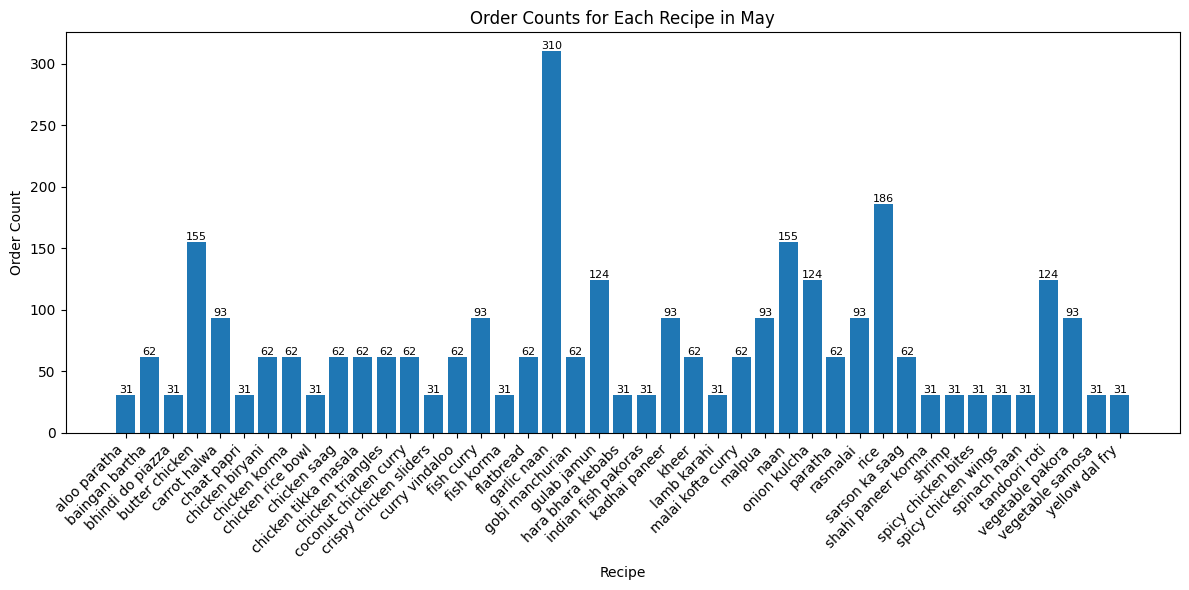

In [12]:
# Filter data for May and group by YearMonth and Recipe
may_orders = df_restaurant_food[df_restaurant_food['DateTime'].dt.month == 5]
order_counts = may_orders.groupby(['YearMonth', 'MenuItem']).size().reset_index(name='Order Count')

# Plot the data
plt.figure(figsize=(12, 6))
bars = plt.bar(order_counts['MenuItem'], order_counts['Order Count'])
plt.xlabel('Recipe')
plt.ylabel('Order Count')
plt.title('Order Counts for Each Recipe in May')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Annotate each bar with the count of orders
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=8)

plt.show()

 **Orders placed in June**

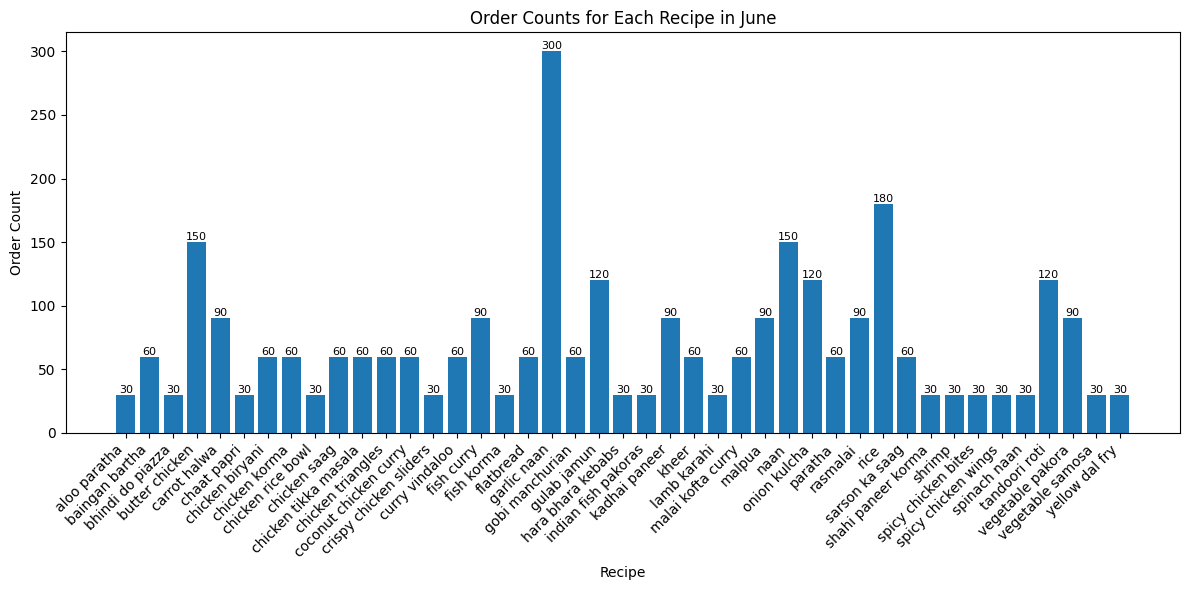

In [13]:
# Filter data for June and group by YearMonth and Recipe
june_orders = df_restaurant_food[df_restaurant_food['DateTime'].dt.month == 6]
order_counts = june_orders.groupby(['YearMonth', 'MenuItem']).size().reset_index(name='Order Count')

# Plot the data
plt.figure(figsize=(12, 6))
bars = plt.bar(order_counts['MenuItem'], order_counts['Order Count'])
plt.xlabel('Recipe')
plt.ylabel('Order Count')
plt.title('Order Counts for Each Recipe in June')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Annotate each bar with the count of orders
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=8)

plt.show()